In [10]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import json
# Cosmetics:
import seaborn as sns
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.colormaps['RdYlBu']
cm_rev = plt.colormaps['RdYlBu_r']

### Create dataframe with all results

In [11]:
# Load combined json file (created with collectData.py)
jsonFile = 'atlas_susy_2018_14_HeHe_scan.json'
with open(jsonFile, 'r') as f:
    data = json.load(f)

columns = list(data[0].keys())
# Expand efficiencies for all lifetimes
dfRecast = pd.json_normalize(
    data,
    meta=columns
)

dfRecast['tau0_ns'] = (dfRecast['tau0_ns']).apply(lambda x: float(f'{x:.2e}'))
dfRecast['width_GeV'] = 6.582e-16/dfRecast['tau0_ns']

## Plot Efficiencies and MC Uncertainties

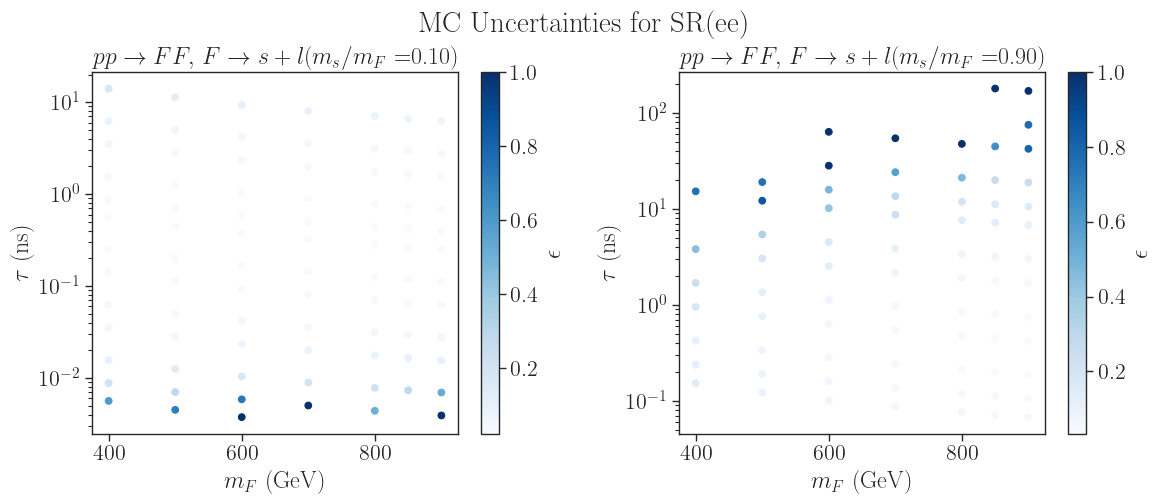

In [12]:
fig,axList =plt.subplots(figsize=(12,5),nrows=1,ncols=2)

title = r'$p p \to F F,\, F \to s + l$'
# Select only points with very light DM
xDMList_all = list((dfRecast['m5000022']/dfRecast['mLLP']).unique())
xDMList = [min(xDMList_all), max(xDMList_all)]


for iax,ax in enumerate(axList):
    xDM = xDMList[iax]
    df = dfRecast[dfRecast['m5000022']/dfRecast['mLLP'] == xDM]
    x = df['mLLP']
    y = df['tau0_ns']
    tit_append = ''
    z = df['AccEffCuts_ee_err']/df['AccEffCuts_ee']

    im = ax.scatter(x,y,c=z,cmap='Blues')
    ax.set_yscale('log')
    ax.set_ylabel(r'$\tau$ (ns)')
    ax.set_xlabel(r'$m_{F}$ (GeV)')
    fig.colorbar(im, ax=ax, label=r'$\epsilon$')

    ax.set_title(title + r'($m_{s}/m_{F} = $' + f'{xDM:1.2f})')

plt.tight_layout()
plt.suptitle('MC Uncertainties for SR(ee)', y=1.02)
plt.show()

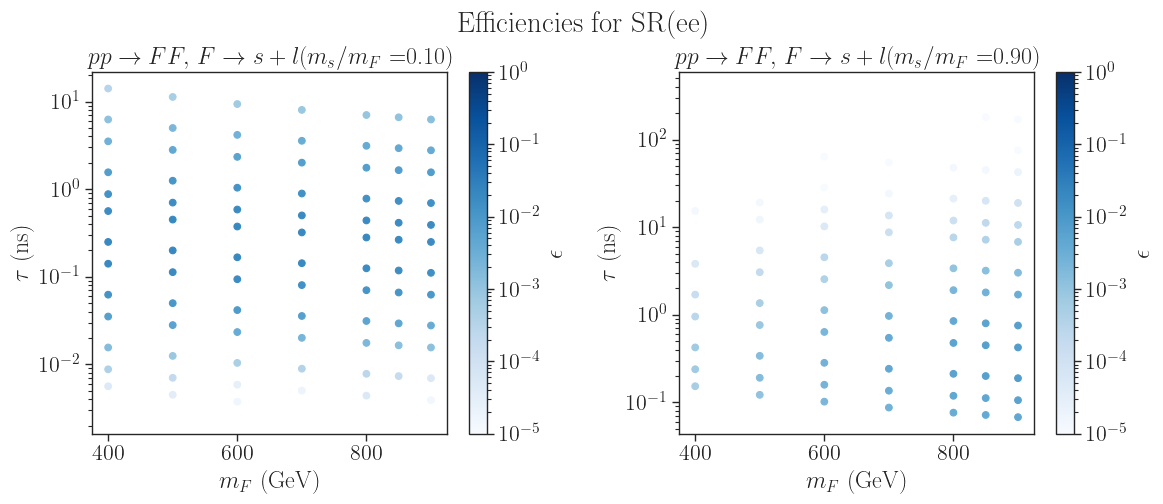

In [13]:
fig,axList =plt.subplots(figsize=(12,5),nrows=1,ncols=2)

title = r'$p p \to F F,\, F \to s + l$'
# Select only points with very light DM


for iax,ax in enumerate(axList):
    xDM = xDMList[iax]
    df = dfRecast[dfRecast['m5000022']/dfRecast['mLLP'] == xDM]
    x = df['mLLP']
    y = df['tau0_ns']
    tit_append = ''
    z = df['AccEffCuts_ee']

    im = ax.scatter(x,y,c=z,cmap='Blues', norm=LogNorm(vmin=1e-5, vmax=1.0))
    ax.set_yscale('log')
    ax.set_ylabel(r'$\tau$ (ns)')
    ax.set_xlabel(r'$m_{F}$ (GeV)')
    fig.colorbar(im, ax=ax, label=r'$\epsilon$')

    ax.set_title(title + r'($m_{s}/m_{F} = $' + f'{xDM:1.2f})')

plt.tight_layout()
plt.suptitle('Efficiencies for SR(ee)', y=1.02)
plt.show()

## Plot Exclusion Curve

### Get ATLAS official exclusion curve for selectron pair production

In [14]:
atlas_curve = np.genfromtxt('./ATLAS_data/HEPData-ins1831504-v2-csv/Observedselectronlimits.csv',
                            delimiter=',',comments='#')
atlas_curve = atlas_curve[~np.isnan(atlas_curve[:,0])]

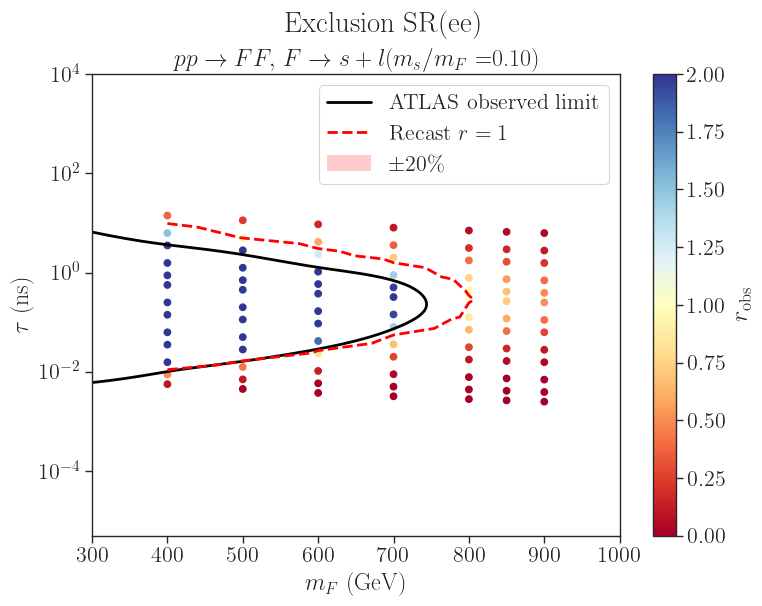

In [15]:
fig,ax =plt.subplots(figsize=(8,6),nrows=1,ncols=1)

xDM = min(xDMList_all)
df = dfRecast[dfRecast['m5000022']/dfRecast['mLLP'] == xDM]

x = df['mLLP']
y = df['tau0_ns']
r = 1.0/df['muUL_observed']


im = ax.scatter(x,y,c=r,cmap=cm,vmin=0,vmax=2)

# Recast observed-like contour from r = 1
cont_r1 = ax.tricontour(
    x.to_numpy(),
    y.to_numpy(),
    r.to_numpy(),
    levels=[1.0],
    colors='red',
    linewidths=2.0,
    linestyles='--',
    zorder=3
    )

atlas_line, = ax.plot(atlas_curve[:,0], atlas_curve[:,1], label='ATLAS observed limit',linewidth=2,c='black')

ax.set_yscale('log')
ax.set_ylabel(r'$\tau$ (ns)')
ax.set_xlabel(r'$m_{F}$ (GeV)')
fig.colorbar(im, ax=ax, label=r'$r_{\rm obs}$')

ax.set_title(title + r'($m_{s}/m_{F} = $' + f'{xDM:1.2f})')
ax.set_xlim(300.,1000.)
ax.set_ylim(5e-6,1e4)

# Use a proxy artist so the r=1 contour appears with a dashed line in the legend
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
recast_proxy = Line2D([0], [0], color='red', linestyle='--', linewidth=2.0, label=r'Recast $r=1$')
band_proxy = Patch(facecolor='red', alpha=0.2, edgecolor='none', label=r'$\pm 20$\%')
ax.legend(handles=[atlas_line, recast_proxy, band_proxy])

plt.tight_layout()
plt.suptitle('Exclusion SR(ee)', y=1.02)
plt.show()

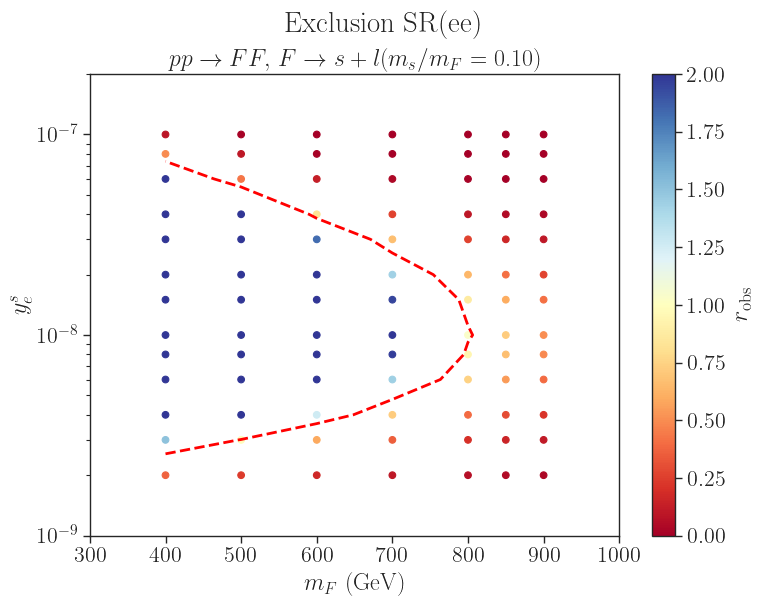

In [16]:
fig,ax =plt.subplots(figsize=(8,6),nrows=1,ncols=1)

xDM = min(xDMList_all)
df = dfRecast[dfRecast['m5000022']/dfRecast['mLLP'] == xDM]

x = pd.to_numeric(df['mLLP'], errors='coerce')
y = pd.to_numeric(df['frblock_2'], errors='coerce')
r = 1.0/pd.to_numeric(df['muUL_observed'], errors='coerce')

plot_df = pd.DataFrame({'x': x, 'y': y, 'r': r}).dropna()
plot_df = plot_df[plot_df['y'] > 0]

im = ax.scatter(plot_df['x'], plot_df['y'], c=plot_df['r'], cmap=cm, vmin=0, vmax=2)

# Build a regular grid and contour on it to avoid degenerate triangulation in highly anisotropic axes
grid = plot_df.pivot_table(index='y', columns='x', values='r', aggfunc='mean').sort_index().sort_index(axis=1)
Xg, Yg = np.meshgrid(grid.columns.to_numpy(dtype=float), grid.index.to_numpy(dtype=float))
Rg = np.ma.masked_invalid(grid.to_numpy(dtype=float))

vals = Rg.compressed()
if vals.size > 0 and vals.min() <= 1.0 <= vals.max():
    cont_r1 = ax.contour(
        Xg,
        Yg,
        Rg,
        levels=[1.0],
        colors='red',
        linewidths=2.0,
        linestyles='--',
        zorder=3
        )

ax.set_yscale('log')
ax.set_ylabel(r'$y_{e}^s$')
ax.set_xlabel(r'$m_{F}$ (GeV)')
fig.colorbar(im, ax=ax, label=r'$r_{\rm obs}$')

ax.set_title(title + r'($m_{s}/m_{F} = $' + f' {xDM:1.2f})')
ax.set_xlim(300.,1000.)
ax.set_ylim(1e-9,2e-7)


plt.tight_layout()
plt.suptitle('Exclusion SR(ee)', y=1.02)
plt.show()

0.9484494602053345


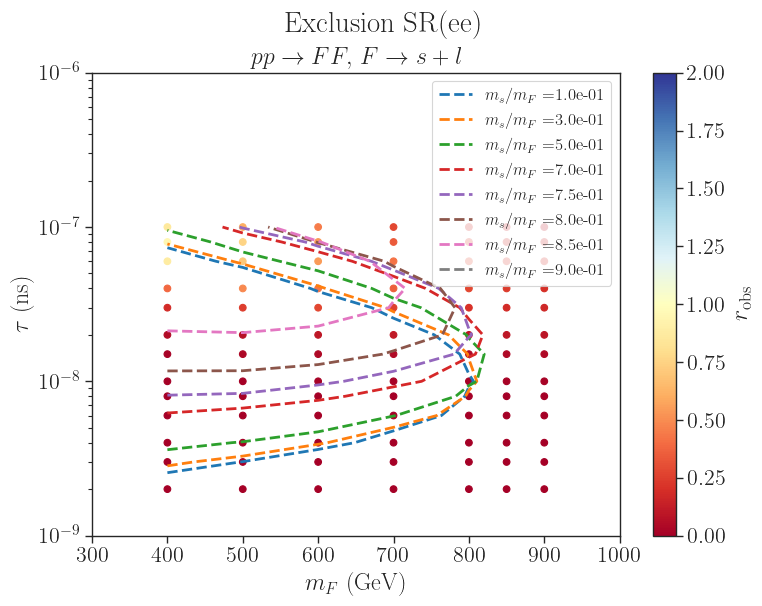

In [39]:
fig,ax =plt.subplots(figsize=(8,6),nrows=1,ncols=1)

# atlas_line, = ax.plot(atlas_curve[:,0], atlas_curve[:,1], label='ATLAS observed limit',linewidth=2,c='black')

xDM_values = sorted((dfRecast['m5000022']/dfRecast['mLLP']).unique())
color_map = plt.colormaps['tab10']
recast_handles = []

for i, xDM in enumerate(xDM_values):
    df = dfRecast[dfRecast['m5000022']/dfRecast['mLLP'] == xDM]

    x = df['mLLP']
    # y = df['tau0_ns']
    y = df['frblock_2']
    r = 1.0/df['muUL_observed']
    color = color_map(i % color_map.N)
    if xDM == 0.9:
        im = ax.scatter(x,y, c=r, cmap=cm, vmin=0, vmax=2)
        print(max(r))


    # # Recast observed-like contour from r = 1
    # cont_r1 = ax.tricontour(
    #     x.to_numpy(),
    #     y.to_numpy(),
    #     r.to_numpy(),
    #     levels=[1.0],
    #     colors=[color],
    #     linewidths=2.0,
    #     linestyles='--',
    #     zorder=3
    #     )
    plot_df = pd.DataFrame({'x': x, 'y': y, 'r': r}).dropna()
    plot_df = plot_df[plot_df['y'] > 0]

    # Build a regular grid and contour on it to avoid degenerate triangulation in highly anisotropic axes
    grid = plot_df.pivot_table(index='y', columns='x', values='r', aggfunc='mean').sort_index().sort_index(axis=1)
    Xg, Yg = np.meshgrid(grid.columns.to_numpy(dtype=float), grid.index.to_numpy(dtype=float))
    Rg = np.ma.masked_invalid(grid.to_numpy(dtype=float))

    vals = Rg.compressed()
    if vals.size > 0 and vals.min() <= 1.0 <= vals.max():
        cont_r1 = ax.contour(
            Xg,
            Yg,
            Rg,
            levels=[1.0],
            colors=[color],
            linewidths=2.0,
            linestyles='--',
            zorder=3
            )
    recast_proxy = Line2D([0], [0], color=color, linestyle='--', 
                          linewidth=2.0, label=r'$m_{s}/m_{F} = $' + f'{xDM:1.1e}')
    recast_handles.append(recast_proxy)

ax.set_yscale('log')
ax.set_ylabel(r'$\tau$ (ns)')
ax.set_xlabel(r'$m_{F}$ (GeV)')
fig.colorbar(im, ax=ax, label=r'$r_{\rm obs}$')

ax.set_title(title)
ax.set_xlim(300.,1000.)
ax.set_ylim(1e-9,1e-6)

# Use proxy artists so contour styles/colors appear correctly in the legend
ax.legend(handles=recast_handles,fontsize=12,loc='upper right')

plt.tight_layout()
plt.suptitle('Exclusion SR(ee)', y=1.02)
plt.show()

### Plot as a function of mass compression

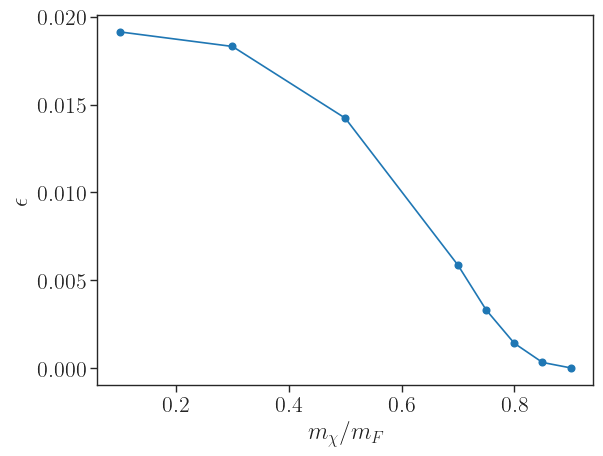

In [21]:
mLLP = 500.0
yDM = 1e-8
df = dfRecast[(dfRecast['mLLP'] == mLLP) & (dfRecast['frblock_2'] == yDM)]
x = (df['m5000022']/df['mLLP']).to_numpy()
y = df['AccEffCuts_ee'].to_numpy()
y = y[np.argsort(x)]
x = np.sort(x)

plt.plot(x, y, marker='o')
plt.xlabel(r'$m_{\chi}/m_{F}$')
plt.ylabel(r'$\epsilon$')
# plt.title(r'$p p \to F F,\, F \to s + l$' + r'($m_{F} = ' + f'{mLLP} GeV, y = {y} ns)')
plt.show()

In [27]:
print(y)
print(x)

[1.91350508e-02 1.83054948e-02 1.42274780e-02 5.86276256e-03
 3.31573573e-03 1.41608661e-03 3.26087682e-04 1.62894489e-05]
[0.1  0.3  0.5  0.7  0.75 0.8  0.85 0.9 ]


In [24]:
xsec_500_pb = 1.95
xsec_UL = 0.02
eff = xsec_UL/(xsec_500_pb*9.0)
print(eff)

0.0011396011396011395
